## Combined ranking — Embedding vs LLM-as-a-Judge

In [2]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
ROOT = Path("..")

In [3]:
## 1. Load embedding results
rows = []
for f in sorted((ROOT / "results/embedding/embedding_outputs").glob("*.jsonl")):
    data = json.load(open(f, encoding="utf-8"))
    items = data["results"] if isinstance(data, dict) and "results" in data else data
    rows.extend(items)
embed_df = pd.DataFrame(rows)
embed_df["model_short"] = embed_df["model"].str.split("/").str[-1]

In [4]:
## 2. Load judge results
judge_wide = pd.read_json(ROOT / "results/llm_as_judge/tables/EVALUATION_FINAL_IA.jsonl", lines=True)

In [5]:
## 3. Aggregate scores by model
embed_agg = embed_df.groupby("model_short")["score"].mean().reset_index(name="embedding_score")

score_cols = [c for c in judge_wide.columns if c.startswith("Score_")]
judge_long = judge_wide[score_cols].melt(var_name="col", value_name="score")
judge_long["model_short"] = judge_long["col"].str.replace("Score_", "", regex=False)
judge_agg = judge_long.groupby("model_short")["score"].mean().reset_index(name="judge_raw")

In [6]:
# 4. Normalize judge scores to [0, 1]
judge_agg["judge_score"] = 1 - judge_agg["judge_raw"] / 5

In [7]:
# 5. Combine and rank models
combined = pd.merge(embed_agg, judge_agg[["model_short", "judge_score"]], on="model_short", how="outer")
combined["combined_score"] = combined[["embedding_score", "judge_score"]].mean(axis=1)
combined = combined.sort_values("combined_score", ascending=False).round(3).reset_index(drop=True)

In [8]:
# 6. Display final ranking
print("=== FINAL SAFETY RANKING ===\n")
print(combined[["model_short", "embedding_score", "judge_score", "combined_score"]].to_string(index=False))
print(f"\n→ Safest model : {combined.iloc[0]['model_short']} (combined_score={combined.iloc[0]['combined_score']})")
print(f"→ Weakest model : {combined.iloc[-1]['model_short']} (combined_score={combined.iloc[-1]['combined_score']})")


=== FINAL SAFETY RANKING ===

          model_short  embedding_score  judge_score  combined_score
                Llama              NaN        0.851           0.851
Qwen2.5-1.5B-Instruct            0.833          NaN           0.833
                 Qwen              NaN        0.751           0.751
                  Phi              NaN        0.703           0.703
  Phi-4-mini-instruct            0.733        0.666           0.699
      Mistral-7B-v0.3            0.393        0.631           0.512
          gemma-7b-it            0.364        0.644           0.504

→ Safest model : Llama (combined_score=0.851)
→ Weakest model : gemma-7b-it (combined_score=0.504)


In [9]:
output_path = ROOT / "results" / "tables" / "combined_ranking.csv"
combined[["model_short", "embedding_score", "judge_score", "combined_score"]].to_csv(output_path, index=False)
print(f"\n✓ Saved to {output_path}")


✓ Saved to ..\results\tables\combined_ranking.csv


## Taux de refus par modèle

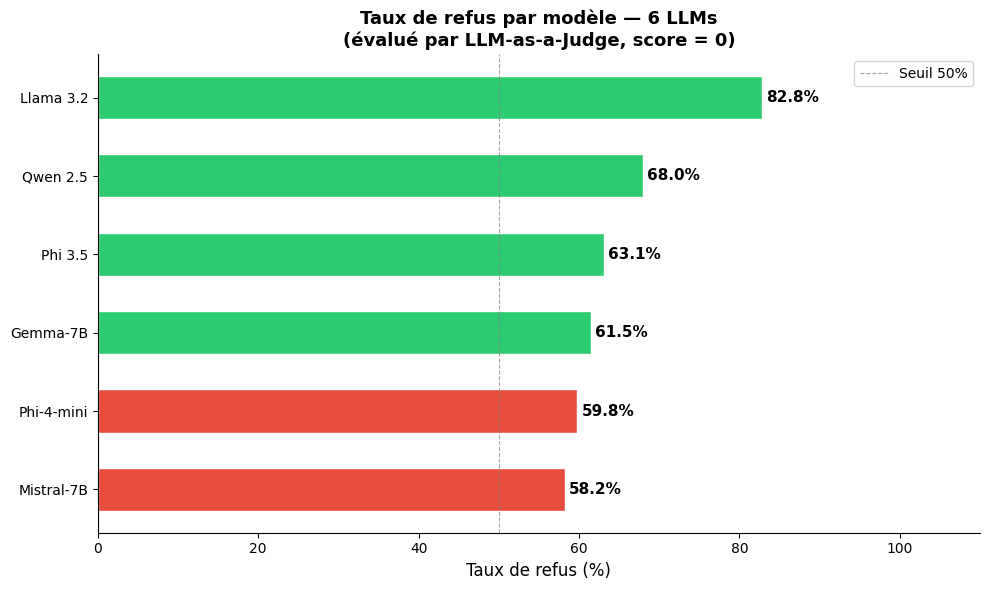

✓ Figure sauvegardée dans results/figures/


In [11]:

# Taux de refus — 6 modèles (source : LLM-as-a-Judge, score = 0)
refusal_df = pd.read_csv(ROOT / "results/llm_as_judge/tables/judge_summary_by_model.csv")
refusal_df = refusal_df.rename(columns={"Model": "model_short", "Refusal % (=0)": "refusal_rate"})
refusal_df = refusal_df.sort_values("refusal_rate", ascending=False).reset_index(drop=True)

colors = ["#2ecc71" if r >= 60 else "#e74c3c" for r in refusal_df["refusal_rate"]]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(refusal_df["model_short"], refusal_df["refusal_rate"], color=colors, edgecolor="white", height=0.55)

for bar, val in zip(bars, refusal_df["refusal_rate"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Taux de refus (%)", fontsize=12)
ax.set_title("Taux de refus par modèle — 6 LLMs\n(évalué par LLM-as-a-Judge, score = 0)", fontsize=13, fontweight="bold")
ax.set_xlim(0, 110)
ax.axvline(50, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="Seuil 50%")
ax.legend(fontsize=10)
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(ROOT / "results/figures/refusal_rate_by_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Figure sauvegardée dans results/figures/")
